### 2D line attractor system anaylsis

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from aux import format_plot
from matplotlib.colors import ListedColormap
import seaborn as sns

plt.rcParams['font.family'] = 'Helvetica'

In [2]:
# Get a palette and convert to colormap
cmap = sns.color_palette("magma", as_cmap=True) 

In [3]:
def plot_flow_field(a, b, v_0=0, x_0=0, nonlinearity='relu', save_name='2D_flow_field'):
    # System parameters
    tau = 1.0
    W = np.array([[a, b],
                  [b,  a]])
    v = np.ones((2)) * v_0
    x0 = np.ones((2)) * x_0
    
    # ReLU function
    def relu(x):
        return np.maximum(0, x)
    
    # Define the system dynamics
    def h_dot(h):
        if nonlinearity == 'relu':
            return (W @ relu(h - v) - h + x0) / tau
        elif nonlinearity == 'tanh':
            return (W @ np.tanh(relu(h - v)) - h + x0) / tau
        else:
            raise NotImplementedError('Nonlinearity not found')
    
    # Grid for plotting
    x_vals = np.linspace(0, 1.2, 10)
    y_vals = np.linspace(0, 1.2, 10)
    X, Y = np.meshgrid(x_vals, y_vals)
    U = np.zeros_like(X)
    V = np.zeros_like(Y)
    
    # Evaluate vector field
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            h = np.array([X[i, j], Y[i, j]])
            dh = h_dot(h)
            U[i, j], V[i, j] = dh
    
    # Normalize vectors for quiver
    magnitude = np.sqrt(U**2 + V**2)
    U_norm = U / (magnitude + 1e-6)
    V_norm = V / (magnitude + 1e-6)
    
    # Plot
    scale = 1
    fig, axs = plt.subplots(1, 1, figsize=(4 * scale, 3 * scale))
    m = axs.quiver(X, Y, U_norm, V_norm, magnitude, cmap=cmap)
    axs.set_xlabel('$h_1$')
    axs.set_ylabel('$h_2$')
    # axs.set_title('Flow Field for $\dot{h} = \\frac{1}{\\tau}(W [h - v]^+ - h + x_0)$')
    # axs.axvline(v[0], color='gray', linestyle='--', alpha=0.5)
    # axs.axhline(v[1], color='gray', linestyle='--', alpha=0.5)
    cbar = fig.colorbar(m, label='Speed')
    # axs.grid(True)
    axs.axis('equal')
    axs.set_xlim(0)
    axs.set_ylim(0)
    axs.set_xticks([0, 0.5, 1])
    axs.set_yticks([0, 0.5, 1])
    format_plot(axs, ticklabelsize=16, axislabelsize=16)
    format_plot(cbar.ax, ticklabelsize=16, axislabelsize=16)
    fig.savefig(f'{save_name}')
    fig.show()

### When are line attractors possible in networks of 2 units?
Aim: investigate systems of 2 neurons with symmetric weight matrices that can behave like line attractors.

I'll begin with ReLU units.

#### Two self-connected ReLU units

Dynamics obey:

$$\dot{\bf{h}} = W [h - v]^+ - h + x_0$$

where

$$
\mathbf{W} = \begin{pmatrix}
a & b \\
b & a
\end{pmatrix}
$$

and $h$ is the hidden field, $v$ is the threshold, and $x_0$ is external input.

#### Self-connected but disconnected neurons

$$
W = \begin{pmatrix}
1 & 0 \\
0 & 1
\end{pmatrix}
$$

with $x_0 = 0$, $v = 0$.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Axes(0.125,0.11;0.62x0.77)
Axes(0.78375,0.11;0.11625x0.77)


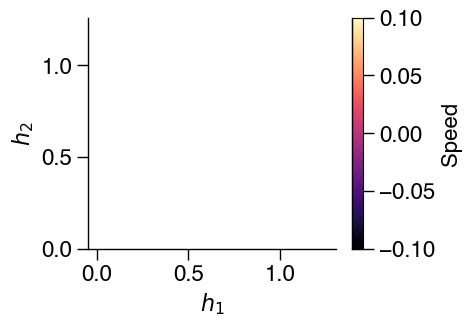

In [22]:
plot_flow_field(1, 0, x_0=0)

#### Line attractor where units trade activity level
$0 < a < 1$, $b = a - 1$, $x_0 > 0$

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Axes(0.125,0.11;0.62x0.77)
Axes(0.78375,0.11;0.11625x0.77)


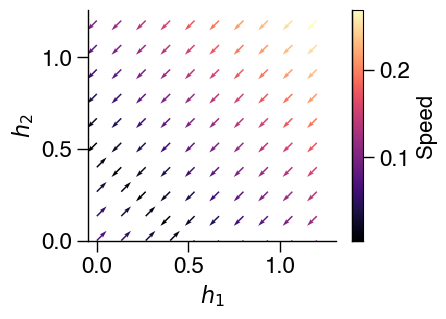

In [29]:
a = 0.9
plot_flow_field(a, a-1, x_0=0.05, save_name='2D_flow_line.svg')


$$
W = \begin{pmatrix}
0.9 & -0.1 \\
-0.1 & 0.9
\end{pmatrix}
$$

$$x_0 = 0.1$$


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Axes(0.125,0.11;0.62x0.77)
Axes(0.78375,0.11;0.11625x0.77)


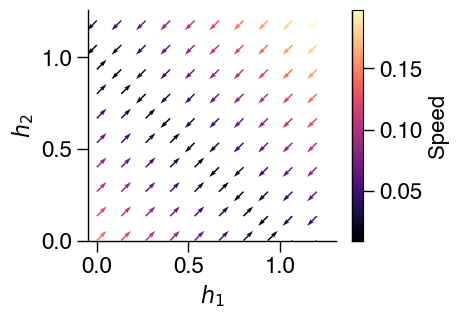

In [30]:
a = 0.9
plot_flow_field(a, a-1, x_0=0.1, save_name='2D_flow_line.svg')


$$
W = \begin{pmatrix}
0.9 & -0.2 \\
-0.2 & 0.9
\end{pmatrix}
$$

$$x_0 = 0.1$$

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Axes(0.125,0.11;0.62x0.77)
Axes(0.78375,0.11;0.11625x0.77)


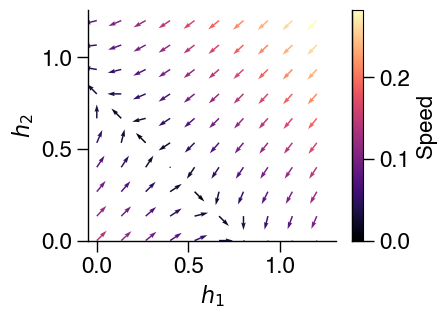

In [31]:
a = 0.9
plot_flow_field(a, a-1.05, x_0=0.1, save_name='2D_flow_2_fixed_point.svg')


$$
W = \begin{pmatrix}
0.9 & 0 \\
0 & 0.9
\end{pmatrix}
$$

$$x_0 = 0.1$$

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Axes(0.125,0.11;0.62x0.77)
Axes(0.78375,0.11;0.11625x0.77)


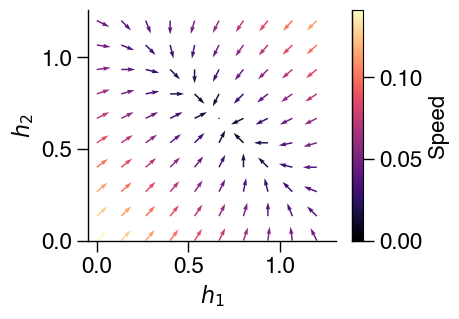

In [32]:
a = 0.9
plot_flow_field(a, a-0.95, x_0=0.1, save_name='2D_flow_1_fixed_point.svg')

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Axes(0.125,0.11;0.62x0.77)
Axes(0.78375,0.11;0.11625x0.77)


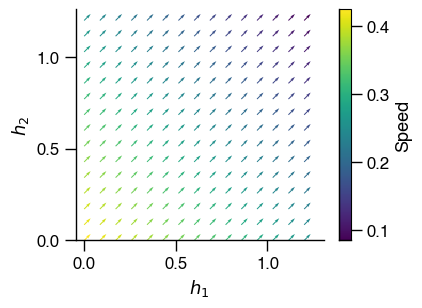

In [77]:
a = 0.9
plot_flow_field(a, a-1, x_0=0.3)

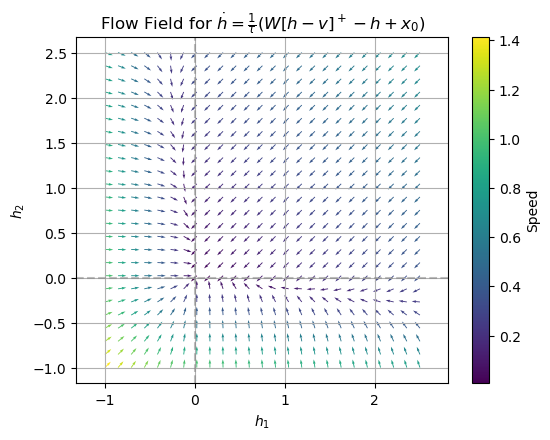

In [4]:
a = 0.9
plot_flow_field(a, a-1, x_0=0)

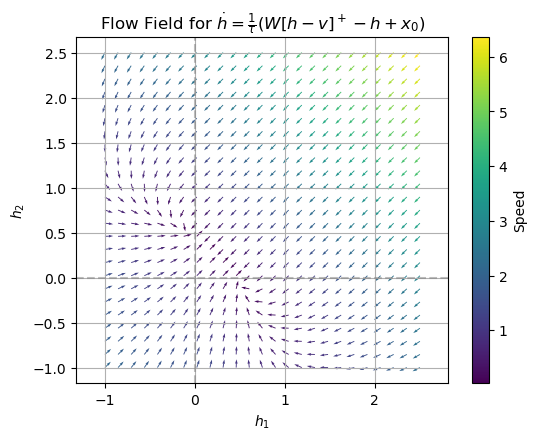

In [23]:
plot_flow_field(0, -1, x_0=0.5)

#### Ramping solution
$a = 0$, $b = 1$, $x_0 = 0$

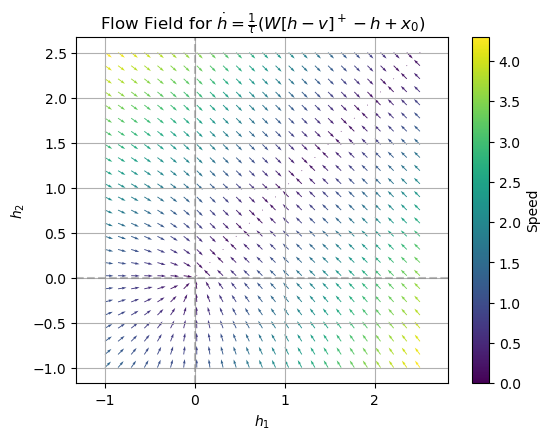

In [8]:
plot_flow_field(0, 1, x_0=0)

#### Network with tanh nonlinearity can approximate seesaw line attractor solution

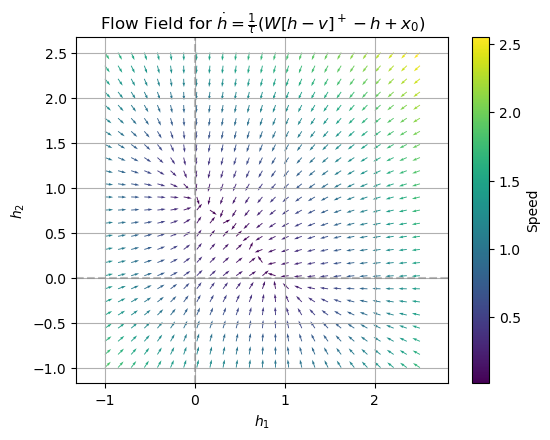

In [40]:
plot_flow_field(0.8, -0.4, x_0=0.3, nonlinearity='tanh')

#### With $x_0 = 0$, only saddle dynamics are possible for activity that trades off

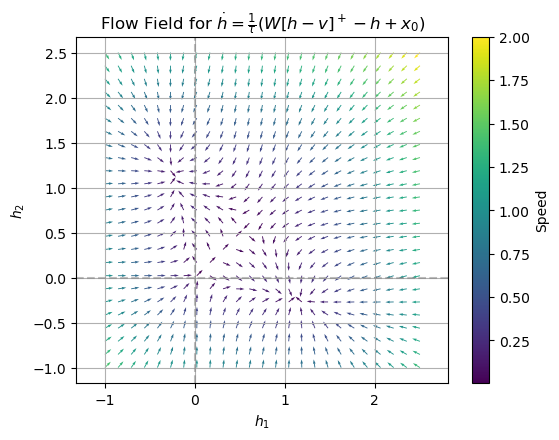

In [48]:
plot_flow_field(1.4, -0.3, x_0=0, nonlinearity='tanh')

In [28]:
def plot_flow_field(beta, save_name='2D_flow_field'):
    
    def w_dot(h):
        return np.square(h[0] - h[1]) - beta
    
    # Grid for plotting
    x_vals = np.linspace(0, 1.2, 10)
    y_vals = np.linspace(0, 1.2, 10)
    X, Y = np.meshgrid(x_vals, y_vals)
    U = np.zeros_like(X)
    V = np.zeros_like(Y)
    
    # Evaluate vector field
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            h = np.array([X[i, j], Y[i, j]])
            dh = w_dot(h)
            U[i, j] = dh
    
    # # Normalize vectors for quiver
    # magnitude = np.sqrt(U**2 + V**2)
    # U_norm = U / (magnitude + 1e-6)
    # V_norm = V / (magnitude + 1e-6)
    
    # Plot
    scale = 1
    fig, axs = plt.subplots(1, 1, figsize=(4 * scale, 3 * scale))
    # m = axs.quiver(X, Y, U_norm, V_norm, magnitude, cmap=cmap)
    m = axs.matshow(U)
    axs.set_xlabel('$h_1$')
    axs.set_ylabel('$h_2$')
    # axs.set_title('Flow Field for $\dot{h} = \\frac{1}{\\tau}(W [h - v]^+ - h + x_0)$')
    # axs.axvline(v[0], color='gray', linestyle='--', alpha=0.5)
    # axs.axhline(v[1], color='gray', linestyle='--', alpha=0.5)
    cbar = fig.colorbar(m, label='Speed')
    # axs.grid(True)
    axs.axis('equal')
    # axs.set_xlim(0)
    # axs.set_ylim(0)
    # axs.set_xticks([0, 0.5, 1])
    # axs.set_yticks([0, 0.5, 1])
    format_plot(axs, ticklabelsize=16, axislabelsize=16)
    format_plot(cbar.ax, ticklabelsize=16, axislabelsize=16)
    fig.savefig(f'{save_name}')
    fig.show()

Axes(0.125,0.11;0.62x0.77)
Axes(0.78375,0.11;0.11625x0.77)


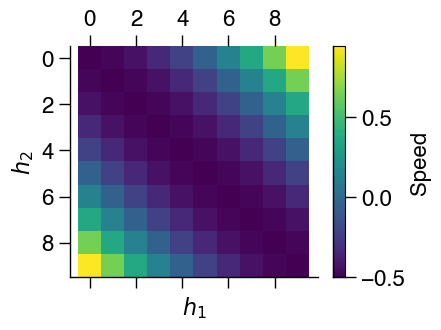

In [29]:
plot_flow_field(beta=0.5, save_name='2D_flow_field')

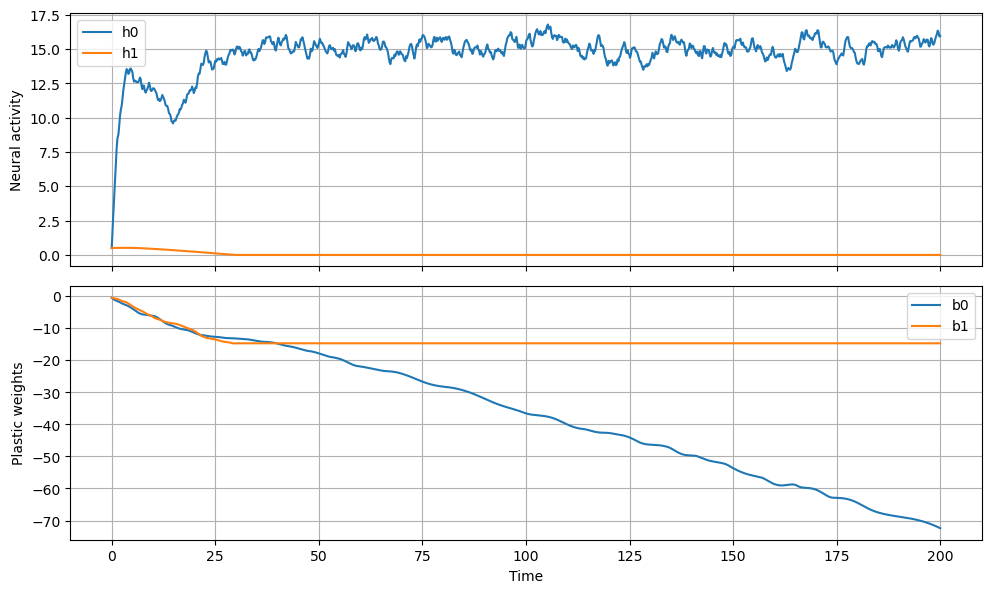

In [103]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

def relu(x):
    return np.maximum(x, 0)

# Constants
a = 0.7
c = 0.25
x_baseline = np.array([1, 1])

t_len = 200  # total time in seconds
dt = 1.0     # spacing of discrete inputs
t_input = np.arange(0, t_len, dt)
x_input_samples = np.random.rand(t_len, 2)

# Interpolate x_input over time so it can be used inside ODE solver
x_input_interp = interp1d(t_input, x_input_samples.T, kind='linear', bounds_error=False, fill_value="extrapolate")

def dynamics(t, y):
    h = y[:2]
    b = y[2:]

    x_input_t = x_input_interp(t)  # shape (2,)
    h_pos = relu(h)
    h_sum = h_pos.sum()

    dh0 = 0.01 * (a * h_pos[0] + b[0] * h_pos[1] - h[0] + x_baseline[0] + x_input_t[0])
    dh1 = 0.01 * (b[1] * h_pos[0] + a * h_pos[1] - h[1] + x_baseline[1] + x_input_t[1])

    db0 = x_input_t[0] / (1e-1 + h_pos[1]) * (c - h_sum) * 1 if h_pos[1] > 0 else 0
    db1 = x_input_t[1] / (1e-1 + h_pos[0]) * (c - h_sum) * 1 if h_pos[0] > 0 else 0

    # print('db0', db0, x_input_t[0] / (1e-1 + h_pos[1]))
    # print('db1', db1, x_input_t[1] / (1e-1 + h_pos[0]))

    return [dh0, dh1, db0, db1]

# Initial conditions
y0 = [0.5, 0.5, -0.5, -0.5]

# Integration settings
t_span = (0, t_len)
t_eval = np.linspace(*t_span, 1000)

sol = solve_ivp(dynamics, t_span, y0, t_eval=t_eval)

# Plotting
h1, h2, b1, b2 = sol.y

fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axs[0].plot(sol.t, relu(h0), label='h0')
axs[0].plot(sol.t, relu(h1), label='h1')
axs[0].set_ylabel('Neural activity')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(sol.t, b1, label='b0')
axs[1].plot(sol.t, b2, label='b1')
axs[1].set_ylabel('Plastic weights')
axs[1].set_xlabel('Time')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()